# Dimensionality Reduction

**PCA Feature Extraction of FRED and Index Variables**

Author: Pete King

We reduce the dimensionality of the FRED and index variables using Principal Component Analysis (PCA) for a few reasons:
 1. To reduce "noise" in the data and emphasize the singal we want our models to pay attention to
 2. To reduce multicollinearity in the data
 3. To extract a smaller set of features to use as input variables to our models

Rather than lump all variables together in a single run, we separate variables into major groups, based on the correlation analysis we did as part of our data exploration:

 - Volatility indices: VIX, VXN, MOVE
 - Historical volatility for non-volatility indices: Commodities, equity indices, and ETFs
 - Recent returns for non-volatility indices
 - Macroeconomic data and other infrequently reported variables


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

from helpers import data_prep as dp
from helpers import viz

DATA_DIR = Path.cwd().parent / 'data' / 'downsample' / 'W' / 'train-val-test'
TRAIN_DATA_FILE = DATA_DIR / 'train_BASE_DATA.csv'
VAL_DATA_FILE = DATA_DIR / 'val_BASE_DATA.csv'
TEST_DATA_FILE = DATA_DIR / 'test_BASE_DATA.csv'

## I. Data Preparation

### Import financial data

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)
test_df = pd.read_csv(
    TEST_DATA_FILE,
    index_col='date',
    parse_dates=True
)

### Separate features into desired groups

In [3]:
X_cols, _ = dp.get_X_y_cols(train_df, returns=True)
# Volatility indices
vol = ['^MOVE', '^VIX', '^VXN']
# Macroeconomic and other variables
macro = [
    'one_month_yield_diff', 'three_month_yield_diff', 'six_month_yield_diff',
    'one_year_yield_diff', 'two_year_yield_diff', 'five_year_yield_diff',
    'ten_year_yield_diff', 'thirty_year_yield_diff',
    '^TNX_diff',
    'nominal_GDP_chg', 'real_GDP_chg', 'debt_to_GDP_chg', 'debt_interest_chg',
    'consumer_price_index_chg', 'core_PCI_chg',
    'personal_consumption_expenditure_chg', 'core_PCE_chg',
    'producer_price_index_chg', 'unemployment_rate_chg',
    'teenager_unemployment_rate_chg', 'adult_unemployment_rate_chg',
    'male_unemployment_rate_chg', 'female_unemployment_rate_chg',
    'average_duration_of_unemployment_chg',
    'initial_jobless_claims_chg',
    'continued_jobless_claims_chg'
]
# Historical volatility and recent return for non-volatility indices
p_vol = re.compile(r'.+_vol-h$')
p_ret = re.compile(r'.+_ret-h$')
hvol = [var for var in X_cols if p_vol.match(var) is not None]
hret = [var for var in X_cols if p_ret.match(var) is not None]

### Scale data

In [4]:
scaler = MinMaxScaler()
# Take care to fit scaler only to training data
X_train = pd.DataFrame(
    scaler.fit_transform(train_df[X_cols]),
    index=train_df.index,
    columns=X_cols
)
X_val = pd.DataFrame(
    scaler.transform(val_df[X_cols]),
    index=val_df.index,
    columns=X_cols
)
X_test = pd.DataFrame(
    scaler.transform(test_df[X_cols]),
    index=test_df.index,
    columns=X_cols
)

## II. Apply PCA for feature extraction

*Note: We only fit PCA to training data to avoid data leakage*

In [5]:
# Volatility indices
pca_vol = PCA()
X_train_vol = pca_vol.fit_transform(X_train[vol])
X_val_vol = pca_vol.transform(X_val[vol])
X_test_vol = pca_vol.transform(X_test[vol])
# Macroeconomic data
pca_macro = PCA()
X_train_macro = pca_macro.fit_transform(X_train[macro])
X_val_macro = pca_macro.transform(X_val[macro])
X_test_macro = pca_macro.transform(X_test[macro])
# Historical volatility of non-volatility indices
pca_hvol = PCA()
X_train_hvol = pca_hvol.fit_transform(X_train[hvol])
X_val_hvol = pca_hvol.transform(X_val[hvol])
X_test_hvol = pca_hvol.transform(X_test[hvol])
# Recent returns for non-volatility indices
pca_hret = PCA()
X_train_hret = pca_hret.fit_transform(X_train[hret])
X_val_hret = pca_hret.transform(X_val[hret])
X_test_hret = pca_hret.transform(X_test[hret])

### Scree plots: Explained variance ratio

#### Volatility Indices

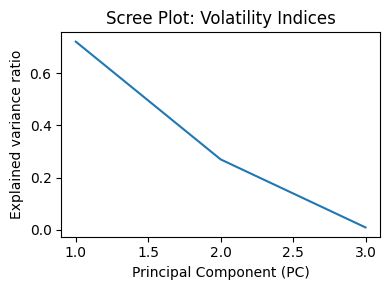

In [6]:
data = np.asarray(
    [(i + 1, ratio) for i, ratio in enumerate(pca_vol.explained_variance_ratio_)]
)
viz.elbow_plot(
    data=data,
    title='Scree Plot: Volatility Indices',
    xlabel='Explained variance ratio',
    ylabel='Principal Component (PC)'
)

In [7]:
pca_vol.explained_variance_ratio_

array([0.72037301, 0.26993648, 0.00969051])

The first principal component alone explains 72% of the variation in the volatility indexes.  Taking the first two components would capture 99% of the variation.  Since the volatility indexes were consistently ranked among the top features (from examination of regression coefficients and decision tree feature importances), we decide to keep the top two components to include nearly all of the variation in these features.  It's also worth stressing that these indices are based on advanced economic models designed to predict overall market volatility -- the very reason they are so valuable as features.

#### Macroeconomic Data

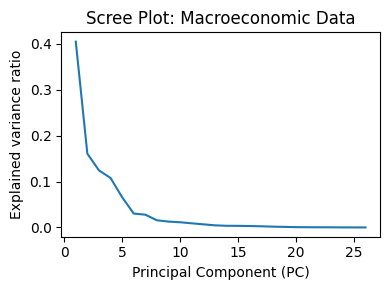

In [8]:
data = np.asarray(
    [(i + 1, ratio) for i, ratio in enumerate(pca_macro.explained_variance_ratio_)]
)
viz.elbow_plot(
    data=data,
    title='Scree Plot: Macroeconomic Data',
    xlabel='Explained variance ratio',
    ylabel='Principal Component (PC)'
)

In [9]:
pca_macro.explained_variance_ratio_

array([4.05139193e-01, 1.60861908e-01, 1.24441518e-01, 1.07895127e-01,
       6.59402336e-02, 3.02888966e-02, 2.78605979e-02, 1.56193592e-02,
       1.27418869e-02, 1.13042556e-02, 9.03286814e-03, 6.79062494e-03,
       4.60758393e-03, 3.60836992e-03, 3.47555755e-03, 3.04608731e-03,
       2.53899650e-03, 1.72272057e-03, 1.20584686e-03, 6.03727276e-04,
       4.56484314e-04, 3.46933403e-04, 3.05653665e-04, 9.08647494e-05,
       5.20137886e-05, 2.26917328e-05])

The first four principal components explain 80% of the variation in macroeconomic data.  This also coincides roughly with a visible bend in the elbow of the scree plot.

#### Historical Volatility (of non-volatility indices)

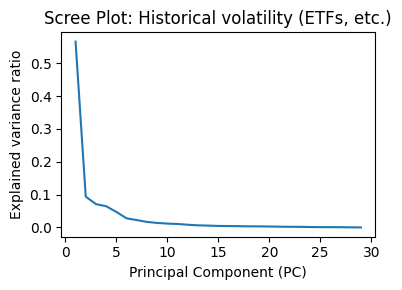

In [10]:
data = np.asarray(
    [(i + 1, ratio) for i, ratio in enumerate(pca_hvol.explained_variance_ratio_)]
)
viz.elbow_plot(
    data=data,
    title='Scree Plot: Historical volatility (ETFs, etc.)',
    xlabel='Explained variance ratio',
    ylabel='Principal Component (PC)'
)

In [11]:
pca_hvol.explained_variance_ratio_

array([5.65824332e-01, 9.37925437e-02, 7.11666266e-02, 6.46386374e-02,
       4.74115225e-02, 2.78349118e-02, 2.24934792e-02, 1.68771822e-02,
       1.37628984e-02, 1.17836450e-02, 1.07190519e-02, 8.24060101e-03,
       6.46255793e-03, 5.68881869e-03, 4.65873745e-03, 4.28811627e-03,
       3.92987616e-03, 3.42637833e-03, 3.26206193e-03, 2.85278345e-03,
       2.39273234e-03, 2.02034711e-03, 1.90218420e-03, 1.36150909e-03,
       9.92012042e-04, 9.52490816e-04, 7.61249936e-04, 4.12738317e-04,
       8.99742336e-05])

The first four principal components explain 80% of the variance in historical volatility for all non-volatility indices.

#### Recent Returns (of non-volatility indices)

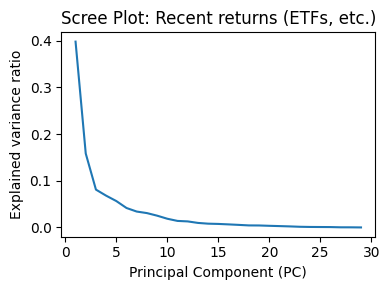

In [12]:
data = np.asarray(
    [(i + 1, ratio) for i, ratio in enumerate(pca_hret.explained_variance_ratio_)]
)
viz.elbow_plot(
    data=data,
    title='Scree Plot: Recent returns (ETFs, etc.)',
    xlabel='Explained variance ratio',
    ylabel='Principal Component (PC)'
)

In [13]:
pca_hret.explained_variance_ratio_

array([3.98331665e-01, 1.58482837e-01, 8.11193835e-02, 6.81381387e-02,
       5.65717876e-02, 4.17012513e-02, 3.40787453e-02, 3.08009384e-02,
       2.52768669e-02, 1.86824556e-02, 1.40159615e-02, 1.29763288e-02,
       9.74318899e-03, 8.12050792e-03, 7.55150953e-03, 6.58536509e-03,
       5.51375237e-03, 4.38296121e-03, 4.25800421e-03, 3.53745016e-03,
       2.91310809e-03, 2.26627745e-03, 1.45516872e-03, 1.08250857e-03,
       9.42580602e-04, 8.14494247e-04, 3.22770406e-04, 2.81262610e-04,
       5.27311844e-05])

We need seven principal components from return data to explain 80% of the variance.  However, considering the low correlation of returns with volatility, we only take the first three principal components, which is where we see a bend in the elbow of the scree plot.  These first three principal components explain 62 percent of the variance.

## III. Save Principal Features

In selecting which principal features to retain, want to strike a balance between capturing variation in the data and increasing the complexity of our models.  As our investigations with the full feature set have shown, not all the variation in these features is relevant to to our target variables.  We choose to retain roughly 80 percent of the variance for each group of features:

 - First 2 principal components for the volatility indices
 - First 4 principal components for the macroeconomic variables
 - First 4 principal components for historical volatility of ETFs, etc.
 - First 3 principal components for recent returns of ETFs, etc.

### Principal Features: Training Data

In [14]:
# Create PCA column labels
vol_cols = [
    'PCA_vol-1', 'PCA_vol-2'
]
macro_cols = [
    'PCA_macro-1', 'PCA_macro-2', 'PCA_macro-3', 'PCA_macro-4'
]
hvol_cols = [
    'PCA_hvol-1', 'PCA_hvol-2', 'PCA_hvol-3', 'PCA_hvol-4'
]
hret_cols = [
    'PCA_hret-1', 'PCA_hret-2', 'PCA_hret-3'
]
pca_cols = vol_cols + macro_cols + hvol_cols + hret_cols
# Create PCA DataFrame for extracted training features
train_data = np.asarray(
    [
        *[X_train_vol[:, i] for i in range(len(vol_cols))],
        *[X_train_macro[:, i] for i in range(len(macro_cols))],
        *[X_train_hvol[:, i] for i in range(len(hvol_cols))],
        *[X_train_hret[:, i] for i in range(len(hret_cols))]
    ]
)
train_data = train_data.reshape(-1, len(train_data))

In [15]:
pca_train_df = pd.DataFrame(
    train_data,
    columns=pca_cols,
    index=train_df.index
)
pca_train_df

,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_hvol-1,PCA_hvol-2,PCA_hvol-3,PCA_hvol-4,PCA_hret-1,PCA_hret-2,PCA_hret-3
date,,,,,,,,,,,,,
2015-10-11,0.020393,-0.050569,-0.083967,-0.058499,-0.067576,-0.002795,-0.072643,-0.079753,-0.077507,0.104312,0.002316,-0.090883,-0.038069
2015-10-18,0.144258,0.192679,0.113998,0.055174,0.166992,0.274276,0.162710,0.094806,0.020584,0.025118,-0.079002,-0.063618,-0.125022
2015-10-25,-0.056647,-0.121334,-0.111703,-0.079352,-0.104368,-0.112265,-0.092717,-0.139361,-0.126741,-0.026842,0.062775,0.137901,-0.058733
2015-11-01,-0.094917,-0.100208,-0.130422,-0.170856,-0.163098,-0.172140,-0.177181,-0.103069,-0.153181,-0.053642,-0.100108,-0.192236,-0.164075
2015-11-08,-0.147312,-0.094768,-0.184241,-0.089133,0.072228,0.023532,-0.047020,-0.073972,-0.018724,-0.103848,-0.095369,-0.133983,-0.082019
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-10-30,0.098672,0.161029,-0.227526,0.136163,0.062461,-0.004914,0.156810,0.008527,-0.395601,-0.118113,0.114547,-0.234414,-0.077232
2022-11-06,-0.083704,-0.022727,0.023433,0.075600,0.020540,0.339727,0.243327,0.262418,-0.089171,0.264705,0.204808,0.100751,-0.195060
2022-11-13,0.645380,-0.089868,-0.151042,0.134764,0.002418,0.286366,0.291214,-0.344037,0.419037,0.225218,-0.038603,0.300944,-0.253458


### Principal Features: Validation Data

In [16]:
# Create PCA DataFrame for extracted validation features
val_data = np.asarray(
    [
        *[X_val_vol[:, i] for i in range(len(vol_cols))],
        *[X_val_macro[:, i] for i in range(len(macro_cols))],
        *[X_val_hvol[:, i] for i in range(len(hvol_cols))],
        *[X_val_hret[:, i] for i in range(len(hret_cols))]
    ]
)
val_data = val_data.reshape(-1, len(val_data))

In [17]:
pca_val_df = pd.DataFrame(
    val_data,
    columns=pca_cols,
    index=val_df.index
)
pca_val_df

,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_hvol-1,PCA_hvol-2,PCA_hvol-3,PCA_hvol-4,PCA_hret-1,PCA_hret-2,PCA_hret-3
date,,,,,,,,,,,,,
2023-01-01,0.379490,0.324226,0.266594,0.293677,0.202360,0.199527,0.296241,0.281669,0.382223,0.324424,0.514936,0.753482,0.658234
2023-01-08,0.394917,0.462256,0.269479,0.268835,0.257667,0.316367,0.251307,0.290794,0.428139,0.230494,0.190296,0.129897,0.133858
2023-01-15,0.165722,0.299733,0.175087,0.143733,0.152060,0.250998,0.194094,0.278830,0.195640,0.105820,0.127879,0.078703,0.167393
2023-01-22,0.233605,0.308943,0.348249,0.435391,0.386905,0.213727,0.189446,0.159799,0.102800,0.128429,0.181078,0.142059,0.135292
2023-01-29,0.144512,0.170647,0.103891,0.109015,0.077884,0.121868,0.107411,0.153405,0.134965,0.113956,0.114747,0.096617,0.023890
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-04,0.033142,0.211928,-0.111973,-0.127393,-0.026908,0.053090,0.129759,0.121123,-0.108792,-0.032632,-0.087161,0.037866,0.090022
2024-08-11,-0.147428,0.104897,0.041201,0.024257,0.031721,0.120308,0.201242,0.226685,-0.245335,-0.463942,-0.094987,0.001723,0.065348
2024-08-18,-0.225463,0.049400,0.068010,-0.019308,0.072923,-0.012787,-0.310804,0.281183,-0.278663,-0.225311,0.141284,0.001053,0.089268


### Principal Features: Test Data

In [18]:
# Create PCA DataFrame for extracted validation features
test_data = np.asarray(
    [
        *[X_test_vol[:, i] for i in range(len(vol_cols))],
        *[X_test_macro[:, i] for i in range(len(macro_cols))],
        *[X_test_hvol[:, i] for i in range(len(hvol_cols))],
        *[X_test_hret[:, i] for i in range(len(hret_cols))]
    ]
)
test_data = test_data.reshape(-1, len(test_data))

In [19]:
pca_test_df = pd.DataFrame(
    test_data,
    columns=pca_cols,
    index=test_df.index
)
pca_test_df

,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_hvol-1,PCA_hvol-2,PCA_hvol-3,PCA_hvol-4,PCA_hret-1,PCA_hret-2,PCA_hret-3
date,,,,,,,,,,,,,
2024-10-06,0.175372,0.307316,0.297471,0.362294,0.404494,0.098772,0.143853,0.104325,0.041689,-0.042538,-0.004732,0.118681,0.085364
2024-10-13,0.084550,0.158710,0.094374,0.026794,0.088143,0.087420,0.012317,0.112452,0.213929,0.275130,0.244487,0.157035,0.212195
2024-10-20,0.707787,0.730656,0.461414,0.324320,0.253895,0.239169,0.134346,0.243278,0.116216,0.075973,0.169422,0.136178,0.052941
2024-10-27,0.068033,0.041189,0.024411,-0.009882,0.091353,-0.023145,-0.035998,-0.029539,-0.001721,0.023541,-0.050651,-0.043936,-0.028637
2024-11-03,-0.036989,0.127487,0.100027,-0.037351,-0.027406,0.057492,0.110123,0.164362,-0.031760,-0.065124,-0.040880,-0.125474,-0.153499
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-30,0.272630,-0.301440,-0.049359,0.121365,0.179619,-0.417207,-0.157146,0.088702,-0.000250,-0.122490,-0.077100,0.104701,0.020327
2025-12-07,-0.080639,0.404930,0.028811,-0.007219,-0.068325,0.247587,-0.011951,0.143141,-0.195879,0.280870,0.234937,0.080930,0.266239
2025-12-14,-0.531028,0.444433,0.326177,-0.454943,-0.263333,0.072559,-0.253867,0.436138,-0.105573,-0.038158,0.082391,-0.001411,-0.104422


### Save Principal Features as CSV files

This time we create a combined CSV file with all base data and PCA together for convenience.

In [20]:
# Combine base data with PCA data
complete_train_df = pd.concat([pca_train_df, train_df], axis=1)
complete_val_df = pd.concat([pca_val_df, val_df], axis=1)
complete_test_df = pd.concat([pca_test_df, test_df], axis=1)

In [21]:
# Save final combined DataFrames with scaled features as CSV files
complete_train_df.to_csv(
    DATA_DIR / 'train_PCA_data.csv',
    index_label='date'
)
complete_val_df.to_csv(
    DATA_DIR / 'val_PCA_data.csv',
    index_label='date'
)
complete_test_df.to_csv(
    DATA_DIR / 'test_PCA_data.csv',
    index_label='date'
)